<a href="https://colab.research.google.com/github/AnshSharma16/Machine-learning-with-Python-Projects/blob/main/Customer_Segmentation_Using_KMeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
from google.colab import files
upload=files.upload()

Saving Test.csv to Test (1).csv


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
df=pd.read_csv('Test.csv')

In [21]:
df.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1
0,458989,Female,Yes,36,Yes,Engineer,0.0,Low,1.0,Cat_6
1,458994,Male,Yes,37,Yes,Healthcare,8.0,Average,4.0,Cat_6
2,458996,Female,Yes,69,No,NaN,0.0,Low,1.0,Cat_6
3,459000,Male,Yes,59,No,Executive,11.0,High,2.0,Cat_6
4,459001,Female,No,19,No,Marketing,NaN,Low,4.0,Cat_6


In [22]:
df.isnull().sum()/df.shape[0]*100

,0
ID,0.000000
Gender,0.000000
Ever_Married,1.903312
Age,0.000000
Graduated,0.913590
Profession,1.446517
Work_Experience,10.239817
Spending_Score,0.000000
Family_Size,4.301485
Var_1,1.218120


In [24]:
for column in df.columns:
  if df[column].dtype=='object':
    df[column].fillna(df[column].mode()[0],inplace=True)
  else:
    df[column].fillna(df[column].mean(),inplace=True)

<ipython-input-24-09fbb00b4882>:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].mean(),inplace=True)
<ipython-input-24-09fbb00b4882>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

In [25]:
df.isnull().sum()

,0
ID,0
Gender,0
Ever_Married,0
Age,0
Graduated,0
Profession,0
Work_Experience,0
Spending_Score,0
Family_Size,0
Var_1,0


In [26]:
df.drop(['ID'],axis=1,inplace=True)

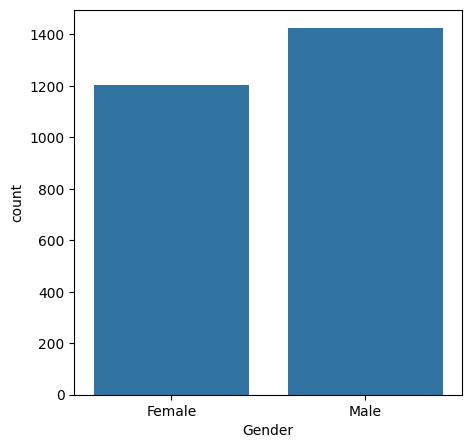

In [29]:
plt.figure(figsize=(5,5))
sns.countplot(x='Gender',data=df)
plt.show()

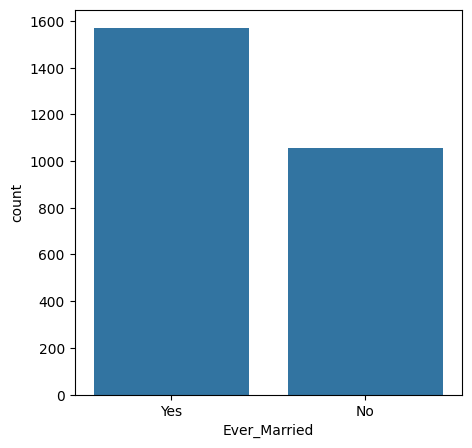

In [30]:
plt.figure(figsize=(5,5))
sns.countplot(x='Ever_Married',data=df)
plt.show()

In [38]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df=df.apply(le.fit_transform)
df.head()

,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1
0,0,1,16,1,2,0,2,0,5
1,1,1,17,1,5,9,0,4,5
2,0,1,46,0,0,0,2,0,5
3,1,1,37,0,4,12,1,1,5
4,0,0,1,0,8,3,2,4,5


In [51]:
from sklearn.cluster import KMeans
inertias=[]

In [52]:
for k in range(1,11):
  kmeans=KMeans(n_clusters=k, random_state=42)
  kmeans.fit(df)
  inertias.append(kmeans.inertia_)

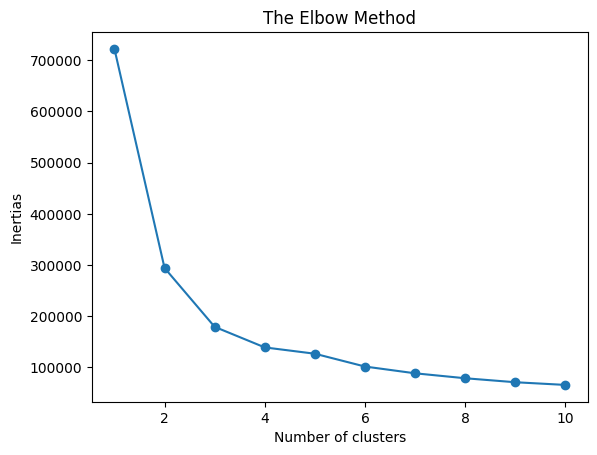

In [53]:
plt.plot(range(1,11),inertias, marker='o')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertias')
plt.show()

In [42]:
df['Cluster'] = kmeans.fit_predict(df[['Age', 'Family_Size']])


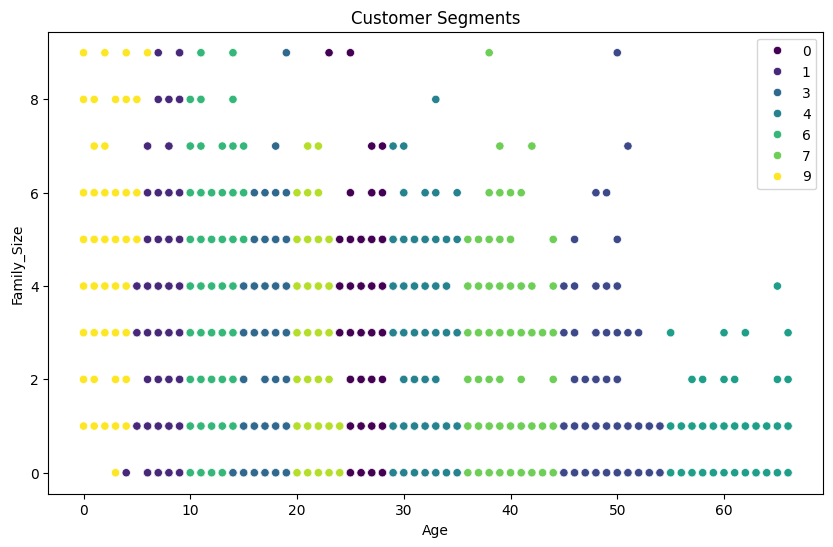

In [45]:
# Scatter plot with clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age', y='Family_Size', hue='Cluster', palette='viridis')
plt.title('Customer Segments')
plt.legend()
plt.show()

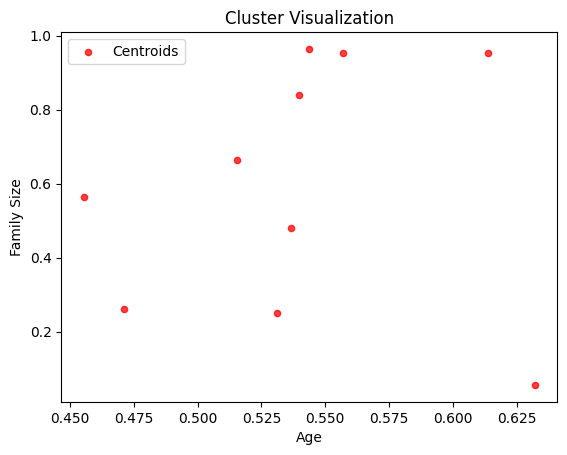

In [57]:
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=20, alpha=0.75, marker='o', label='Centroids')

plt.title("Cluster Visualization")
plt.xlabel("Age")
plt.ylabel("Family Size")
plt.legend()
plt.show()

In [67]:
X = df[['Age', 'Family_Size']].values
kmeans = KMeans(n_clusters=3)
kmeans.fit(X)




KMeans(n_clusters=3)

In [68]:
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1  # Min/Max for Age (X-axis)
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1  # Min/Max for Family_Size (Y-axis)

# Generate the grid of points
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

# Predict the cluster for each point in the grid
Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])  # Predict clusters
Z = Z.reshape(xx.shape)  # Reshape to match the grid shape

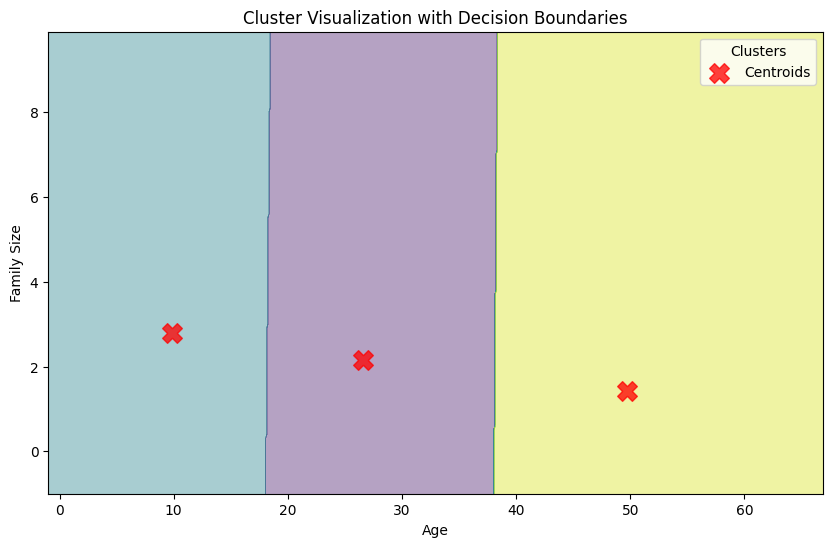

In [72]:
# Plot the decision boundaries
plt.figure(figsize=(10, 6))

# Create a contour plot for the decision boundary
plt.contourf(xx, yy, Z, alpha=0.4, cmap='viridis')

# Optionally, add centroids if needed
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, alpha=0.75, marker='X', label='Centroids')

plt.title("Cluster Visualization with Decision Boundaries")
plt.xlabel("Age")
plt.ylabel("Family Size")
plt.legend(title='Clusters')
plt.show()